# How do Tampa's mapped yard-waste pickup polygons vary by day?

This example uses a [City of Tampa ArcGIS layer URL](https://arcgis.tampagov.net/arcgis/rest/services/OpenData/SolidWaste/MapServer/4) directly, without a checked catalog ID. It groups complete polygon records by the publisher's `COLLECTIONDAYS` field, then compares feature counts with mapped polygon area. The chart describes this layer's geometry, not households served or a guaranteed current pickup schedule.


## 1. Retrieve spatial features through the general client

Direct URL results have `not_checked` catalog status. The package still records provenance and verifies a complete full retrieval.


In [1]:
library(tampaBayOpenData)
library(sf)

layer_url <- "https://arcgis.tampagov.net/arcgis/rest/services/OpenData/SolidWaste/MapServer/4"
pickup <- tbod_get_arcgis_layer(
  layer_url, fields = c("OBJECTID", "COLLECTIONDAYS", "SCHEDULE"),
  spatial = TRUE, out_sr = 4326, total_timeout = 120
)
source <- tbod_provenance(pickup)
stopifnot(isTRUE(source$complete), identical(source$validation_status, "not_checked"),
          nrow(pickup) == source$returned_rows)
print(data.frame(retrieved_at = source$retrieved_at, polygons = nrow(pickup),
                 crs = sf::st_crs(pickup)$input, integrity = source$integrity))


Warning message:
"package 'sf' was built under R version 4.5.3"


Linking to GEOS 3.14.1, GDAL 3.12.1, PROJ 9.7.1; sf_use_s2() is TRUE



         retrieved_at polygons       crs     integrity
1 2026-10-06 22:40:42       43 EPSG:4326 full-manifest


## 2. Count polygons and sum projected areas

UTM zone 17N (EPSG:26917) gives an appropriate local projected area for this exploratory calculation. The result is square kilometres of *polygon records* in each day label; overlaps, if present, would be counted more than once.


In [2]:
day <- trimws(as.character(pickup$COLLECTIONDAYS))
day[is.na(day) | day == ""] <- "(missing)"
area_km2 <- as.numeric(sf::st_area(sf::st_transform(pickup, 26917))) / 1e6
stopifnot(all(is.finite(area_km2)), all(area_km2 >= 0))
polygon_count <- table(day)
area_by_day <- tapply(area_km2, day, sum)
summary <- data.frame(day = names(polygon_count), polygons = as.integer(polygon_count),
                      mapped_area_km2 = round(as.numeric(area_by_day[names(polygon_count)]), 2))
print(summary)
print(table(pickup$SCHEDULE, useNA = "ifany"))


                  day polygons mapped_area_km2
1   Friday Collection       12           46.60
2   Monday Collection       11           40.67
3 Thursday Collection       10           50.11
4  Tuesday Collection       10           38.51



Weekly 
    43 


## 3. Compare the two ways of counting


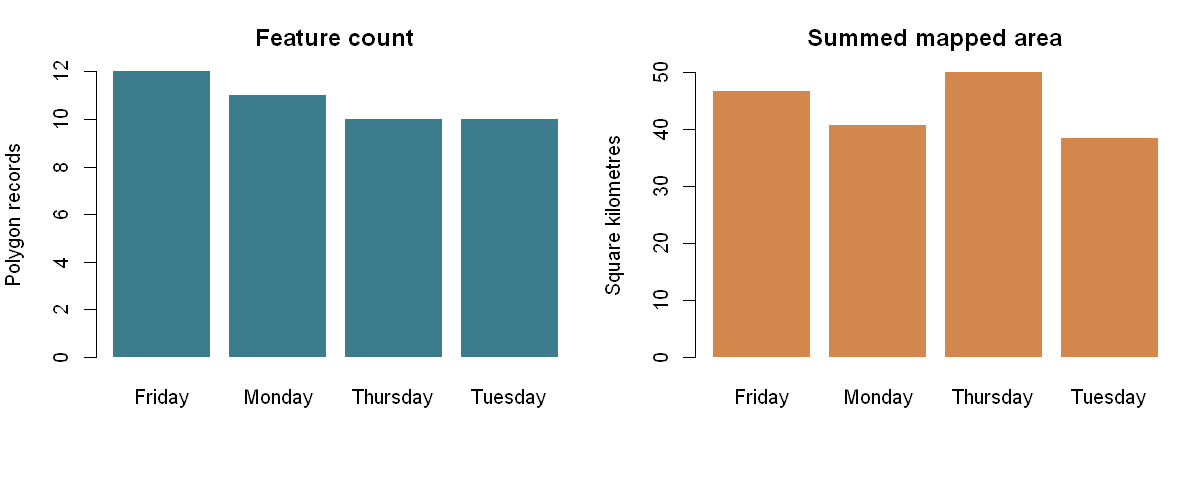

In [3]:
options(repr.plot.width = 10, repr.plot.height = 4)
short_day <- sub(" Collection$", "", summary$day)
previous <- par(mfrow = c(1, 2), mar = c(5, 4, 3, 1))
barplot(summary$polygons, names.arg = short_day,
        col = "#3c7c8c", border = NA, ylab = "Polygon records", main = "Feature count")
barplot(summary$mapped_area_km2, names.arg = short_day,
        col = "#d4874c", border = NA, ylab = "Square kilometres", main = "Summed mapped area")
par(previous)


## What this means

A day with more polygons need not have more mapped area. Neither measure estimates households, route distance, workload, or service eligibility. Verify any practical pickup question with the City's current address-specific service information.
